In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from urllib.parse import urlparse
import requests
from bs4 import BeautifulSoup
import ollama
import time
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [2]:
def search_strategy_urls(query, api_key):
    url = "https://serpapi.com/search"

    params = {
        "q": query,
        "api_key": api_key,
        "engine": "google"
    }

    response = requests.get(url, params=params)
    data = response.json()

    urls = []

    for result in data.get("organic_results", []):
        if "link" in result:
            urls.append(result["link"])

    return urls

queries = [
    'short term stock trading strategies',
    'mean reversion stock trading strategies',
    'long term stock trading strategies',
    'foreign exchange strategies',
    'breakout stock trading strategies',
    'momentum stock trading strategies',
    'simple stock trading strategies',
    'pair trade stock trading strategies',
    'day trading strategies',
    'yahoo! finance stock trading strategies',

    # Trend strategies
    'trend following stock trading strategies',
    'moving average crossover trading strategies',
    'moving average stock trading strategies',
    'MACD stock trading strategies',

    # Reversal / mean reversion
    'reversal stock trading strategies',
    'contrarian stock trading strategies',
    'RSI mean reversion trading strategies',
    'Bollinger Bands trading strategies',

    # Breakout / price action
    'price action stock trading strategies',
    'support and resistance trading strategies',
    'range trading strategies stocks',
    'channel breakout trading strategies',
    'volatility breakout trading strategies',

    # Timeframes
    'intraday stock trading strategies',
    'swing trading strategies stocks',
    'position trading strategies stocks',
    'weekly stock trading strategies',
    'medium term stock trading strategies',

    # Direction
    'long only stock trading strategies',
    'short selling trading strategies',
    'long short stock trading strategies',
    'market neutral trading strategies',

    # Quantitative
    'quantitative stock trading strategies',
    'statistical arbitrage trading strategies',
    'algorithmic stock trading strategies',
    'pairs trading strategies',
    'factor investing trading strategies',

    # Other strategy families
    'gap trading strategies stocks',
    'volume trading strategies stocks',
    'VWAP trading strategies',
    'scalping trading strategies',
    'earnings trading strategies stocks',
    'seasonal stock trading strategies',
    'relative strength trading strategies',
    'technical analysis stock trading strategies',

    # Other assets
    'ETF trading strategies',
    'index trading strategies',
    'futures trading strategies',
    'forex trend trading strategies',
    'forex mean reversion strategies'
]

all_urls = []
API_KEY = "b627b29297e736b18078a2fd5cbcfb770d7fa7b0814701711428b0241d8037c3"

for query in queries:
    urls = search_strategy_urls(query, API_KEY)
    all_urls.extend(urls)

all_urls = list(set(all_urls))

In [3]:
def scrape_strategy(url):
    domain = urlparse(url).netloc
    source = domain.removeprefix("www.").split(".")[0]

    try:
        response = requests.get(
            url,
            headers={"User-Agent": "Mozilla/5.0"},
            timeout=10
        )

        if response.status_code != 200:
            print(f"Failed: {url} ({response.status_code})")
            return None

        soup = BeautifulSoup(response.text, "html.parser")

        for tag in soup(["script", "style", "nav", "footer", "header"]):
            tag.decompose()

        text = soup.get_text(" ", strip=True)

        return {
            "source": source,
            "url": url,
            "raw_text": text
        }

    except requests.RequestException as e:
        return {
            "url": url,
            "raw_text": None,
            "error": str(e)
        }

In [4]:
strategies = []

for url in all_urls:
    strategy = scrape_strategy(url)

    if strategy is not None:
        strategies.append(strategy)

for i, strategy in enumerate(strategies, start=1):
    strategy["id"] = i

with open("data/raw_strategies.json", "w", encoding="utf-8") as f:
    json.dump(strategies, f, indent=4, ensure_ascii=False)

Failed: https://www.forex.com/en-us/trading-guides/trend-trading/ (403)
Failed: https://www.reddit.com/r/Daytrading/comments/1psznoy/anyone_trading_mainly_with_vwap_and_how_do_you/ (403)
Failed: https://forextester.com/blog/trend-trading/?srsltid\u003dAfmBOorzqveHxFNHN1yzZv9AnHDLN6ortZ9wkJq3W6So_M0wolRAvfyo (403)
Failed: https://www.definedgesecurities.com/trading-strategies/category/intraday-trading-strategy/ (403)
Failed: https://www.reddit.com/r/options/comments/1ds471l/weekly_trading/ (403)
Failed: https://www.britannica.com/money/contrarian-investing (403)
Failed: https://www.investopedia.com/terms/t/trading-strategy.asp (402)
Failed: https://www.investopedia.com/terms/c/contrarian.asp (402)
Failed: https://www.reddit.com/r/Daytrading/comments/1gcsgj4/sharing_my_futures_strategy/ (403)
Failed: https://medium.com/@williambdale/algorithmic-thinking-77f53651c17b (403)
Failed: https://www.investopedia.com/trading/introduction-to-momentum-trading/ (402)
Failed: https://www.warriortradi

In [5]:
with open("data/raw_strategies.json", "r", encoding="utf-8") as f:
    strategies = json.load(f)

In [6]:
def extract_strategy(raw_text):
    prompt = f"""
Extract ONE primary stock trading strategy from the text below.

Return exactly:

{{
  "strategy_type": Momentum, Mean Reversion, Trend Following, Breakout,
               Arbitrage, Pairs Trading, Scalping, Other

  "direction": Long, Short, Long/Short, Market Neutral

  "asset_type": Stocks, ETFs, Forex, Futures, Crypto, Multiple

  "timeframe": Intraday, Short-term, Medium-term, Long-term
}}

Rules:
- Extract only ONE primary strategy.
- strategy_type, direction, asset_type, and timeframe must each be
  either ONE string or null.
- Use null, never "Unknown".
- If multiple timeframes appear, choose the timeframe that belongs to
  the primary strategy.
- Do not invent missing information.
- Ignore unrelated webpage content.

TEXT:
{raw_text[:8000]}
"""

    response = ollama.chat(
        model="llama3.2:3b",
        messages=[
            {"role": "user", "content": prompt}
        ],
        format="json"
    )

    return json.loads(response["message"]["content"])

In [7]:
structured_strategies = []

for strategy in strategies:
    try:
        structured = extract_strategy(strategy["raw_text"])

        structured["id"] = strategy["id"]
        structured["source"] = strategy["source"]
        structured["url"] = strategy["url"]

        structured_strategies.append(structured)

        print(f"Finished {strategy['id']}")

        time.sleep(1)

    except Exception as e:
        print(f"Failed on strategy {strategy['id']}: {e}")

Finished 1
Finished 2
Finished 3
Failed on strategy 4: Expecting ':' delimiter: line 15 column 27 (char 162)
Finished 5
Finished 6
Finished 7
Finished 8
Finished 9
Finished 10
Finished 11
Finished 12
Finished 13
Finished 14
Finished 15
Finished 16
Finished 17
Finished 18
Finished 19
Finished 20
Finished 21
Finished 22
Finished 23
Finished 24
Finished 25
Finished 26
Finished 27
Finished 28
Finished 29
Finished 30
Finished 31
Finished 32
Finished 33
Finished 34
Finished 35
Finished 36
Finished 37
Finished 38
Finished 39
Finished 40
Failed on strategy 41: an error was encountered while running the model: CUDA error (status code: 500)
Finished 42
Finished 43
Finished 44
Finished 45
Finished 46
Finished 47
Finished 48
Finished 49
Finished 50
Finished 51
Finished 52
Finished 53
Finished 54
Finished 55
Finished 56
Finished 57
Finished 58
Finished 59
Finished 60
Finished 61
Finished 62
Finished 63
Failed on strategy 64: Unterminated string starting at: line 3 column 15 (char 53)
Finished 65
Fi

In [8]:
def is_valid_strategy(s):
    fields = ["strategy_type", "direction", "asset_type", "timeframe"]
    return sum(s.get(field) is not None for field in fields) >= 3

In [9]:
old_strategies = structured_strategies[:]
structured_strategies = [
    s for s in structured_strategies
    if is_valid_strategy(s)
]

In [10]:
with open("data/structured_strategies.json", "w", encoding="utf-8") as f:
    json.dump(structured_strategies, f, indent=4, ensure_ascii=False)

In [11]:
df = pd.DataFrame(structured_strategies)

df.head()

,strategy_type,direction,asset_type,timeframe,id,source,url,risk_level
0,Opening Range Breakout,Long/Short,Stocks,Intraday,1,mstock,https://www.mstock.com/mlearn/stock-market-cou...,NaN
1,Long-Short,Long/Short,Stocks,Medium-term,3,mymarkets,https://mymarkets.com/en/mymarkets-blog/the-lo...,NaN
2,Mean Reversion,Long/Short,Stocks,4-hour,5,tradingview,https://www.tradingview.com/script/JFIZkwZR-RS...,NaN
3,Market Neutral,Long/Short,Stocks,Medium-term,6,funds,https://funds.aqr.com/Insights/Strategies/Equi...,NaN
4,Contrarian,Long/Short,Stocks,Medium-term,7,bookmap,https://bookmap.com/blog/going-against-the-cro...,NaN


In [12]:
df["asset_type"] = (
    df["asset_type"]
    .astype(str)
    .str.lower()
    .replace({
        "stocks": "stock",
        "nan": None
    })
)

df["timeframe"] = (
    df["timeframe"]
    .astype(str)
    .str.lower()
    .replace({
        "1d": "daily",
        "nan": None
    })
)

df["strategy_type"] = (
    df["strategy_type"]
    .astype(str)
    .str.lower()
    .replace({
        "breakout strategy": "breakout",
        "momentum trading": "momentum",
        "momentum portfolio": "momentum",
        "nan": None
    })
)

In [13]:
categorical = [
    "strategy_type",
    "direction",
    "asset_type",
    "timeframe"
]

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_categorical = encoder.fit_transform(df[categorical])

In [14]:
X_categorical.shape

(191, 47)

In [15]:
X_categorical[0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
       0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.])

In [16]:
encoder.get_feature_names_out()

array(['strategy_type_arbitrage', 'strategy_type_breakout',
       'strategy_type_contrarian', 'strategy_type_equity-market-neutral',
       'strategy_type_gap fill', 'strategy_type_gap trading',
       'strategy_type_long-short', 'strategy_type_long-short equity',
       'strategy_type_long/short equity', 'strategy_type_market neutral',
       'strategy_type_mean reversion',
       'strategy_type_medium term trading',
       'strategy_type_medium-term trading', 'strategy_type_momentum',
       'strategy_type_moving average crossover',
       'strategy_type_opening range breakout',
       'strategy_type_pairs trading', 'strategy_type_position trading',
       'strategy_type_price action', 'strategy_type_range trading',
       'strategy_type_scalping', 'strategy_type_seasonality',
       'strategy_type_short selling', 'strategy_type_spot contract',
       'strategy_type_statistical arbitrage',
       'strategy_type_swing trading', 'strategy_type_trend following',
       'strategy_type_v

In [17]:
X_categorical

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(191, 47))

In [18]:
X_categorical = encoder.fit_transform(df[categorical])

print(X_categorical.shape)
print(encoder.get_feature_names_out())

(191, 47)
['strategy_type_arbitrage' 'strategy_type_breakout'
 'strategy_type_contrarian' 'strategy_type_equity-market-neutral'
 'strategy_type_gap fill' 'strategy_type_gap trading'
 'strategy_type_long-short' 'strategy_type_long-short equity'
 'strategy_type_long/short equity' 'strategy_type_market neutral'
 'strategy_type_mean reversion' 'strategy_type_medium term trading'
 'strategy_type_medium-term trading' 'strategy_type_momentum'
 'strategy_type_moving average crossover'
 'strategy_type_opening range breakout' 'strategy_type_pairs trading'
 'strategy_type_position trading' 'strategy_type_price action'
 'strategy_type_range trading' 'strategy_type_scalping'
 'strategy_type_seasonality' 'strategy_type_short selling'
 'strategy_type_spot contract' 'strategy_type_statistical arbitrage'
 'strategy_type_swing trading' 'strategy_type_trend following'
 'strategy_type_volume reversals' 'direction_Long' 'direction_Long/Short'
 'direction_Market Neutral' 'direction_Short' 'direction_nan'
 '

In [19]:
X = X_categorical

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init="auto"
)

clusters = kmeans.fit_predict(X)

In [20]:
df["cluster"] = clusters

In [21]:
df[
    [
        "strategy_type",
        "direction",
        "asset_type",
        "timeframe",
        "cluster"
    ]
]

,strategy_type,direction,asset_type,timeframe,cluster
0,opening range breakout,Long/Short,stock,intraday,2
1,long-short,Long/Short,stock,medium-term,1
2,mean reversion,Long/Short,stock,4-hour,1
3,market neutral,Long/Short,stock,medium-term,1
4,contrarian,Long/Short,stock,medium-term,1
...,...,...,...,...,...
186,market neutral,Long/Short,stock,medium-term,1
187,long/short equity,Long/Short,stock,intraday,2
188,mean reversion,Long/Short,stock,medium-term,1
189,momentum,Long/Short,stock,intraday,2


In [22]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

In [23]:
X_pca.shape

(191, 2)

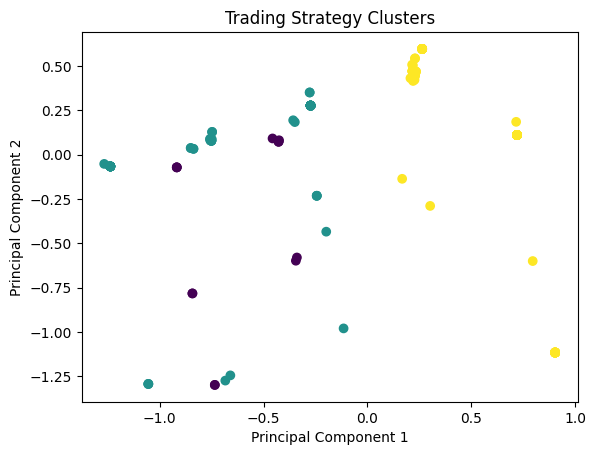

In [24]:


plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Trading Strategy Clusters")

plt.show()

In [25]:
df[
    [
        "strategy_type",
        "direction",
        "asset_type",
        "timeframe",
        "cluster"
    ]
].sort_values("cluster")

,strategy_type,direction,asset_type,timeframe,cluster
40,mean reversion,NaN,stock,long-term,0
44,mean reversion,NaN,stock,long-term,0
39,mean reversion,Long/Short,stock,long-term,0
38,seasonality,Long/Short,stock,long-term,0
111,long/short equity,Long/Short,stock,long-term,0
...,...,...,...,...,...
180,spot contract,Long/Short,forex,intraday,2
184,trend following,Long/Short,stock,intraday,2
187,long/short equity,Long/Short,stock,intraday,2
189,momentum,Long/Short,stock,intraday,2
